In [1]:
# === Step 1: Import Our Toolkits ===
# pandas: For working with our data tables.
# numpy: A powerful tool for numerical operations.
# sqlite3: The specific tool for connecting to SQLite databases.
# matplotlib & seaborn: Our toolkits for creating beautiful charts.
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Make our charts look nice and professional.
sns.set_style("whitegrid")

# === Step 2: Connect to Our Database and Load Data ===
# We create a connection to the database file we made earlier.
db_path = 'hr_analytics.db'
con = sqlite3.connect(db_path)

# The table inside our database is named 'hr_data'. Let's load it.
# pd.read_sql_query() runs an SQL query and loads the result into a pandas DataFrame.
# "SELECT * FROM hr_data" means "Get all columns (*) from the table named hr_data".
query = "SELECT * FROM hr_data"
df = pd.read_sql_query(query, con)

# It's good practice to close the connection when we're done querying.
con.close()

# === Step 3: Initial Investigation ===
# Let's get a feel for our data.
print("--- First 5 Rows of the Data ---")
print(df.head())

print("\n--- Basic Information About the Data ---")
# .info() gives us a summary: column names, number of non-empty values, and data types.
df.info()

--- First 5 Rows of the Data ---
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction Standard

In [2]:
# --- Clue #1: Make Attrition easier to use ---
# The 'Attrition' column has "Yes" and "No". Computers prefer numbers.
# We'll create a new column 'Attrition_numeric' where Yes=1 and No=0.
# This makes it easy to calculate the attrition rate (just find the average of this column!).
df['Attrition_numeric'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# --- Clue #2: Create Age Groups ---
# Looking at individual ages is too detailed. Let's create age groups.
# 'bins' defines the edges of our groups (18-25, 26-35, etc.).
# 'labels' gives a name to each group.
bins = [17, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

# --- Clue #3: Simplify Job Satisfaction ---
# The 'JobSatisfaction' is rated 1-4. Let's make it simpler to read.
# We'll map the numbers to text labels.
satisfaction_map = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}
df['JobSatisfaction_label'] = df['JobSatisfaction'].map(satisfaction_map)

# --- Final Check: Look for missing clues (NaN values) ---
# Our dataset is very clean, but it's a crucial step in any project.
print("\n--- Missing Values Check ---")
print(df.isnull().sum())

# We have a clean and enhanced dataset, ready for analysis!
print("\nNew feature columns created successfully!")


--- Missing Values Check ---
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCur

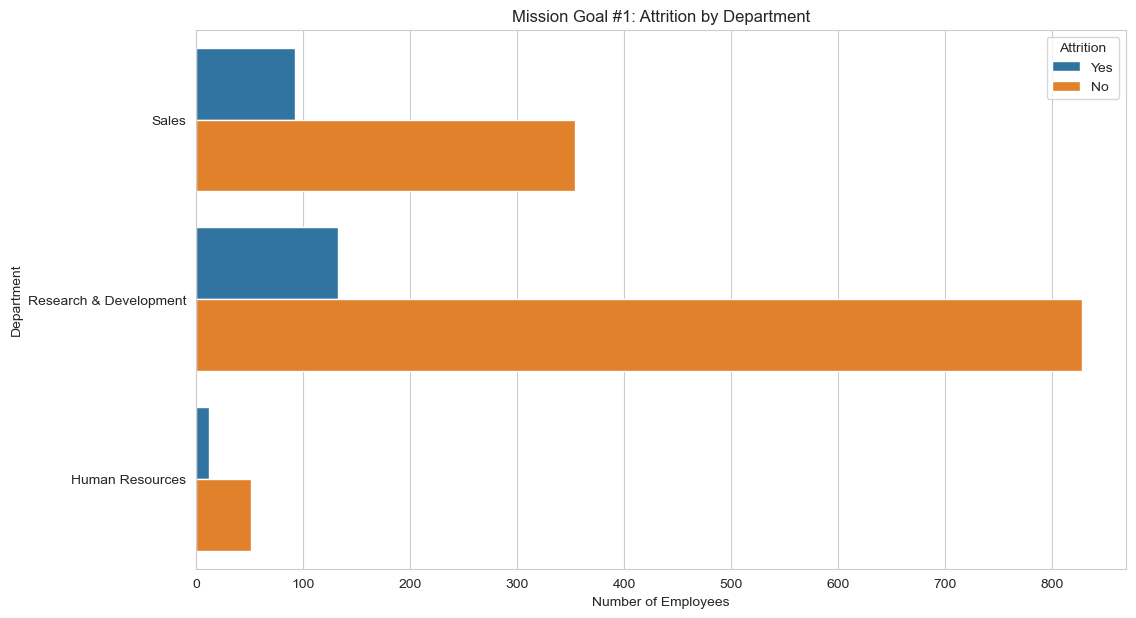

--- Mission #1 Verdict: The overall attrition rate is 16.12%. ---
The chart above shows the raw count of employees who stayed vs. left in each department. R&D has the most leavers by count.


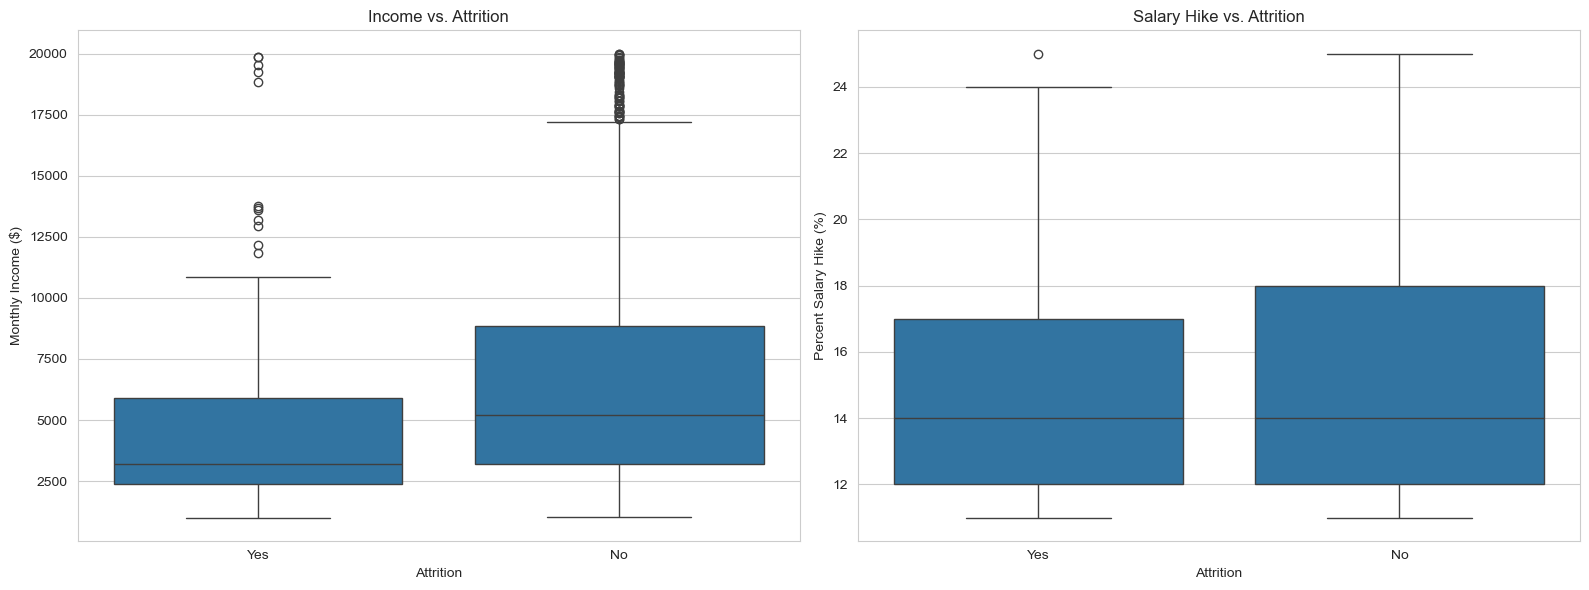


--- Mission #2 Verdict: The box plots show a clear story. ---
Employees who left ('Yes') tend to have a lower median monthly income than those who stayed.
Interestingly, the salary hike percentage does not seem to show a significant difference between the two groups.


In [3]:
# --- Mission Goal #1: Find the Leaky Departments ---
# What are we doing? Calculating the overall attrition rate and then seeing which department has the most people leaving.
overall_attrition_rate = df['Attrition_numeric'].mean() * 100

plt.figure(figsize=(12, 7))
# A countplot is perfect for counting how many people fall into each category.
# We set 'hue' to 'Attrition' to get separate bars for 'Yes' and 'No' for each department.
sns.countplot(data=df, y='Department', hue='Attrition')
plt.title('Mission Goal #1: Attrition by Department')
plt.xlabel('Number of Employees')
plt.ylabel('Department')
plt.show()

print(f"--- Mission #1 Verdict: The overall attrition rate is {overall_attrition_rate:.2f}%. ---")
print("The chart above shows the raw count of employees who stayed vs. left in each department. R&D has the most leavers by count.")

# --- Mission Goal #2: The Money Question ---
# What are we doing? Using box plots to compare the monthly income and salary hike for employees who stayed vs. left.
# A box plot shows the distribution of data (min, max, median, Q1, Q3).
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # Create a figure with two side-by-side plots.

# Plot 1: Monthly Income
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[0])
axes[0].set_title('Income vs. Attrition')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Monthly Income ($)')

# Plot 2: Percent Salary Hike
sns.boxplot(data=df, x='Attrition', y='PercentSalaryHike', ax=axes[1])
axes[1].set_title('Salary Hike vs. Attrition')
axes[1].set_xlabel('Attrition')
axes[1].set_ylabel('Percent Salary Hike (%)')

plt.tight_layout() # Adjusts plots to prevent them from overlapping.
plt.show()

print("\n--- Mission #2 Verdict: The box plots show a clear story. ---")
print("Employees who left ('Yes') tend to have a lower median monthly income than those who stayed.")
print("Interestingly, the salary hike percentage does not seem to show a significant difference between the two groups.")

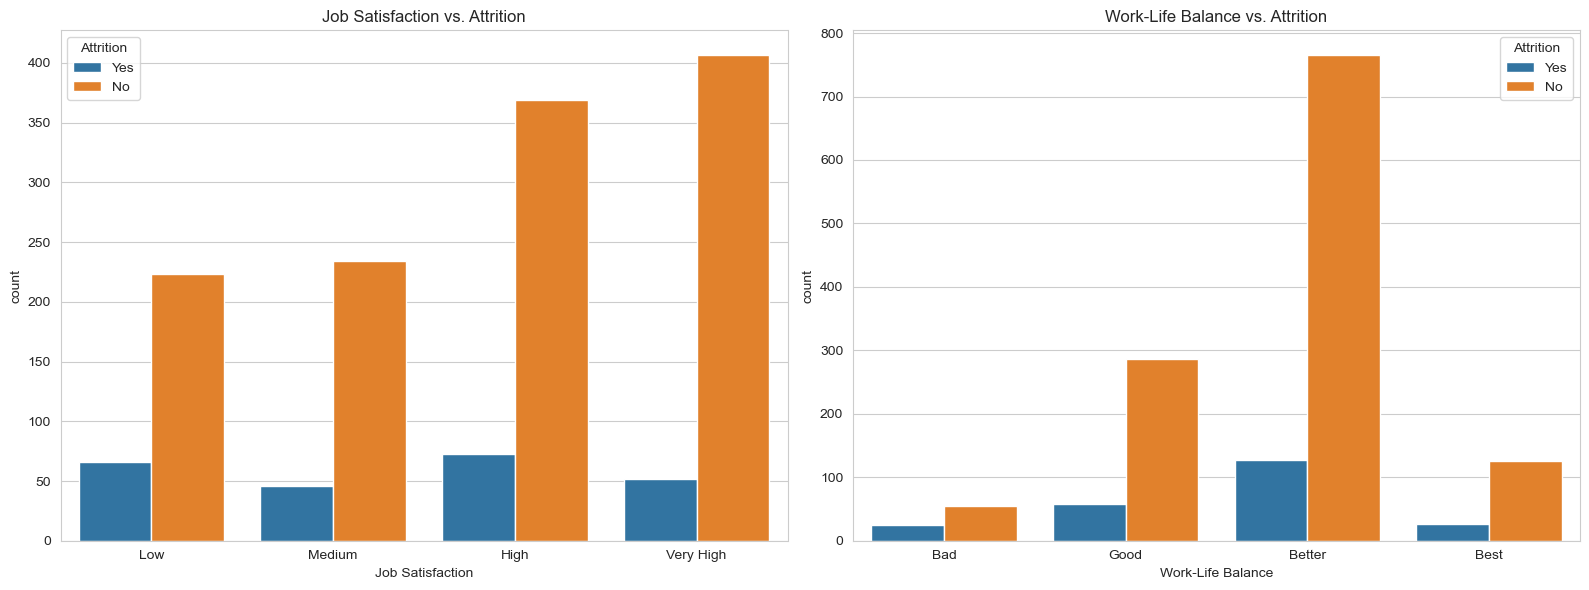


--- Mission #3 Verdict: Happiness matters. ---
Employees with 'Low' job satisfaction have a proportionally higher rate of attrition. A similar trend is visible for those with 'Bad' work-life balance.


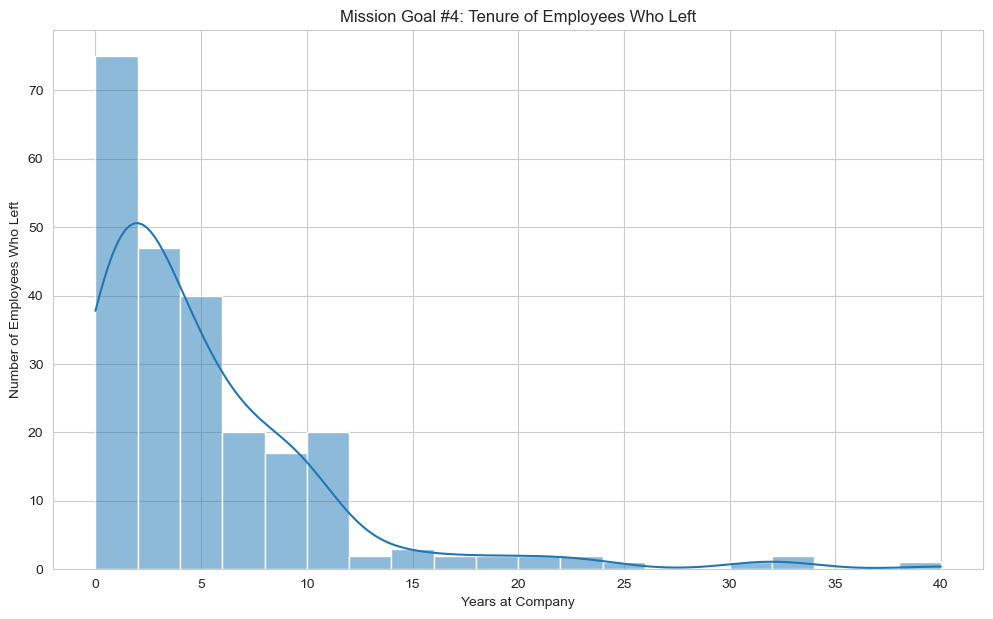


--- Mission #4 Verdict: We are losing new hires. ---
The histogram shows a large spike at the very beginning (0-2 years). This means a significant number of employees are leaving very early in their careers with the company.


In [4]:
# --- Mission Goal #3: The Burnout Factor ---
# What are we doing? Comparing job satisfaction and work-life balance for those who left vs. stayed.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Job Satisfaction
sns.countplot(data=df, x='JobSatisfaction_label', hue='Attrition', ax=axes[0], order=['Low', 'Medium', 'High', 'Very High'])
axes[0].set_title('Job Satisfaction vs. Attrition')
axes[0].set_xlabel('Job Satisfaction')

# Plot 2: Work-Life Balance
# We'll map the numbers to labels directly for this plot.
work_life_map = {1: 'Bad', 2: 'Good', 3: 'Better', 4: 'Best'}
df['WorkLifeBalance_label'] = df['WorkLifeBalance'].map(work_life_map)
sns.countplot(data=df, x='WorkLifeBalance_label', hue='Attrition', ax=axes[1], order=['Bad', 'Good', 'Better', 'Best'])
axes[1].set_title('Work-Life Balance vs. Attrition')
axes[1].set_xlabel('Work-Life Balance')

plt.tight_layout()
plt.show()

print("\n--- Mission #3 Verdict: Happiness matters. ---")
print("Employees with 'Low' job satisfaction have a proportionally higher rate of attrition. A similar trend is visible for those with 'Bad' work-life balance.")


# --- Mission Goal #4: The Loyalty Puzzle ---
# What are we doing? Looking at the years spent at the company for employees who left.
# A histogram shows the distribution of a single numerical variable.
plt.figure(figsize=(12, 7))
# We first filter our data to only include people who left (Attrition == 'Yes').
sns.histplot(data=df[df['Attrition'] == 'Yes'], x='YearsAtCompany', kde=True, bins=20)
plt.title('Mission Goal #4: Tenure of Employees Who Left')
plt.xlabel('Years at Company')
plt.ylabel('Number of Employees Who Left')
plt.show()

print("\n--- Mission #4 Verdict: We are losing new hires. ---")
print("The histogram shows a large spike at the very beginning (0-2 years). This means a significant number of employees are leaving very early in their careers with the company.")

--- Mission #5 Verdict: The Crystal Ball is Ready ---
Model Accuracy: 86.05%

--- The Confusion Matrix ---


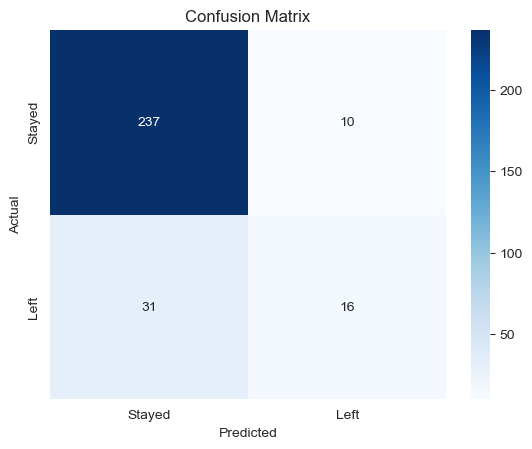


--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294

Recommendation: This model can now be used to identify current employees who have a high risk of leaving. The HR team can then proactively engage with these employees.


In [6]:
# === Step 1: Import Our Modeling Toolkits ===
# We need some expert witnesses from the scikit-learn library.
from sklearn.model_selection import train_test_split # To split our data into training and testing sets.
from sklearn.linear_model import LogisticRegression # Our chosen prediction model.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # Tools to judge our model's performance.
from sklearn.preprocessing import StandardScaler # A tool to scale our numerical data to a standard range.

# === Step 2: Prepare the Data for the Model ===
# Our model only understands numbers. We need to convert text columns into numerical ones.

# We'll create a new DataFrame for our model.
model_df = df.copy()

# Convert all categorical text columns into numbers using 'get_dummies'.
# This creates new columns for each category (e.g., Department_Sales, Department_R&D) with 1s and 0s.
model_df = pd.get_dummies(model_df, columns=['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime'], drop_first=True)

# We can drop columns that are not useful for prediction or that we've already replaced.
# <--- THE FIX IS HERE! We've added 'Over18' to this list.
model_df = model_df.drop(['Attrition', 'EmployeeCount', 'StandardHours', 'EmployeeNumber', 'Over18', 'AgeGroup', 'JobSatisfaction_label', 'WorkLifeBalance_label'], axis=1)

# === Step 3: Define the Mission (Features and Target) ===
# X contains all the clues (features) we will use for prediction.
X = model_df.drop('Attrition_numeric', axis=1)
# y is the target we want to predict (did they leave or not?).
y = model_df['Attrition_numeric']

# === Step 4: Split the Data for a Fair Test ===
# We can't test our model on the same data it learned from. That's cheating!
# We split our data: 80% for training the model, 20% for testing it.
# random_state=42 ensures we get the same split every time we run the code.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# === Step 5: Scale the Numerical Features ===
# Scaling numbers to be in a similar range (e.g., -1 to 1) helps the model learn better.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# === Step 6: Train the Model ===
# We create an instance of our Logistic Regression model and 'fit' it to our training data.
# This is the "learning" step.
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# === Step 7: Make Predictions on the Test Data ===
# Now we use our trained model to predict attrition for the unseen test data.
y_pred = model.predict(X_test)

# === Step 8: The Verdict - How Good is Our Model? ===
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("--- Mission #5 Verdict: The Crystal Ball is Ready ---")
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\n--- The Confusion Matrix ---")
# A confusion matrix tells us where the model got it right and wrong.
# Top-left: Correctly predicted 'Stay'
# Bottom-right: Correctly predicted 'Leave'
# Top-right/Bottom-left: Errors
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\n--- Detailed Classification Report ---")
print(class_report)
print("Recommendation: This model can now be used to identify current employees who have a high risk of leaving. The HR team can then proactively engage with these employees.")

In [8]:
# === Step 1: Create the "Case Files" for Our New Employees ===
# We'll create a dictionary for each employee.
# The keys (like 'Age', 'DailyRate') MUST exactly match the original column names.

# Employee A: Likely to stay
employee_A_data = {
    'Age': 35, 'DailyRate': 1200, 'DistanceFromHome': 2, 'Education': 4,
    'EnvironmentSatisfaction': 4, 'HourlyRate': 85, 'JobInvolvement': 3,
    'JobLevel': 3, 'JobSatisfaction': 4, 'MonthlyIncome': 8500,
    'MonthlyRate': 20000, 'NumCompaniesWorked': 1, 'PercentSalaryHike': 15,
    'PerformanceRating': 3, 'RelationshipSatisfaction': 4, 'StockOptionLevel': 1,
    'TotalWorkingYears': 15, 'TrainingTimesLastYear': 3, 'WorkLifeBalance': 3,
    'YearsAtCompany': 14, 'YearsInCurrentRole': 9, 'YearsSinceLastPromotion': 3,
    'YearsWithCurrManager': 8,
    'BusinessTravel': 'Travel_Rarely', 'Department': 'Research & Development',
    'EducationField': 'Life Sciences', 'Gender': 'Female',
    'JobRole': 'Research Director', 'MaritalStatus': 'Married', 'OverTime': 'No'
}

# Employee B: At risk of leaving
employee_B_data = {
    'Age': 24, 'DailyRate': 450, 'DistanceFromHome': 18, 'Education': 2,
    'EnvironmentSatisfaction': 1, 'HourlyRate': 60, 'JobInvolvement': 2,
    'JobLevel': 1, 'JobSatisfaction': 1, 'MonthlyIncome': 2800,
    'MonthlyRate': 15000, 'NumCompaniesWorked': 3, 'PercentSalaryHike': 11,
    'PerformanceRating': 3, 'RelationshipSatisfaction': 2, 'StockOptionLevel': 0,
    'TotalWorkingYears': 3, 'TrainingTimesLastYear': 2, 'WorkLifeBalance': 1,
    'YearsAtCompany': 2, 'YearsInCurrentRole': 1, 'YearsSinceLastPromotion': 0,
    'YearsWithCurrManager': 1,
    'BusinessTravel': 'Travel_Frequently', 'Department': 'Sales',
    'EducationField': 'Marketing', 'Gender': 'Male',
    'JobRole': 'Sales Representative', 'MaritalStatus': 'Single', 'OverTime': 'Yes'
}

# Convert our dictionaries into pandas DataFrames.
new_employee_A = pd.DataFrame([employee_A_data])
new_employee_B = pd.DataFrame([employee_B_data])

print("--- New Employee Case Files Created ---")

# === Step 2: Prepare the New Data EXACTLY Like the Training Data ===
# This is the most crucial step! We must repeat the same transformations.

def prepare_new_data(df_new, df_original_for_columns):
    """A function to prepare new data for our model."""
    
    # Perform one-hot encoding for categorical variables.
    df_prepared = pd.get_dummies(df_new, columns=['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime'], drop_first=True)
    
    # Get the columns from the original training data (X) to ensure an exact match.
    original_cols = df_original_for_columns.columns
    
    # Reindex the new data to match the training data columns.
    # This adds any missing columns (and fills them with 0) and aligns the order.
    df_prepared = df_prepared.reindex(columns=original_cols, fill_value=0)
    
    return df_prepared

# Prepare both new employee files. We use 'X' (our original feature set before splitting) to get the correct column structure.
employee_A_prepared = prepare_new_data(new_employee_A, X)
employee_B_prepared = prepare_new_data(new_employee_B, X)

# === Step 3: Use the SAME Scaler to Transform the New Data ===
# We do NOT use .fit_transform() here. We only .transform().
# This applies the scaling rules our model learned from the original training data.
employee_A_scaled = scaler.transform(employee_A_prepared)
employee_B_scaled = scaler.transform(employee_B_prepared)

print("--- New Data Prepared and Scaled for Prediction ---")

# === Step 4: Ask the Crystal Ball for its Prediction ===
# .predict() gives a direct 0 (Stay) or 1 (Leave) answer.
prediction_A = model.predict(employee_A_scaled)
prediction_B = model.predict(employee_B_scaled)

# .predict_proba() gives the probability for each outcome [Prob of Staying, Prob of Leaving].
# This is much more useful!
probability_A = model.predict_proba(employee_A_scaled)
probability_B = model.predict_proba(employee_B_scaled)


# === Step 5: Report the Findings (Upgraded with Business Logic) ===

def get_risk_level(probability_of_leaving):
    """Assigns a risk level based on a custom business threshold."""
    prob_percent = probability_of_leaving * 100
    if prob_percent > 30:
        return "HIGH RISK"
    elif 15 <= prob_percent <= 30:
        return "MEDIUM RISK"
    else:
        return "LOW RISK"

print("\n--- CRYSTAL BALL PREDICTION REPORT (Business Edition) ---")

# --- Report for Employee A ---
prob_A_leave = probability_A[0][1]
risk_A = get_risk_level(prob_A_leave)

print("\n--- Analysis for Employee A ---")
print(f"Risk Level: {risk_A}")
print(f"Confidence Score: There is a {prob_A_leave*100:.2f}% calculated probability that this employee will leave.")
print("Recommendation: This employee appears safe. Standard engagement is sufficient.")


# --- Report for Employee B ---
prob_B_leave = probability_B[0][1]
risk_B = get_risk_level(prob_B_leave)

print("\n--- Analysis for Employee B ---")
print(f"Risk Level: {risk_B}")
print(f"Confidence Score: There is a {prob_B_leave*100:.2f}% calculated probability that this employee will leave.")
print("Recommendation: URGENT! This employee is a high flight risk. HR should proactively engage with them to address potential issues (e.g., satisfaction, workload, compensation) immediately.")

--- New Employee Case Files Created ---
--- New Data Prepared and Scaled for Prediction ---

--- CRYSTAL BALL PREDICTION REPORT (Business Edition) ---

--- Analysis for Employee A ---
Risk Level: LOW RISK
Confidence Score: There is a 0.03% calculated probability that this employee will leave.
Recommendation: This employee appears safe. Standard engagement is sufficient.

--- Analysis for Employee B ---
Risk Level: HIGH RISK
Confidence Score: There is a 45.62% calculated probability that this employee will leave.
Recommendation: URGENT! This employee is a high flight risk. HR should proactively engage with them to address potential issues (e.g., satisfaction, workload, compensation) immediately.


In [9]:
# What are we doing? Saving our final, clean DataFrame to a new CSV file.
output_path = 'data_for_dashboard.csv'
df.to_csv(output_path, index=False)

print("\n--- Project Complete ---")
print("Successfully exported the final analysis data to:", output_path)
print("You can now find this file in your D:\\HR_Attrition_Project folder.")
print("Use this file to build your dashboard in Power BI or your preferred BI tool.")


--- Project Complete ---
Successfully exported the final analysis data to: data_for_dashboard.csv
You can now find this file in your D:\HR_Attrition_Project folder.
Use this file to build your dashboard in Power BI or your preferred BI tool.
